# Logistic Regression Baseline
This notebook section loads the final merged KKBox dataset and trains a logistic regression baseline without overloading the local memory. The goal is to establish an interpretable starting point for identifying churn risk before comparing with more complex models.

## 1. Load final dataset

In [ ]:
import pandas as pd
import numpy as np
import os

# Update this path if needed
file_path = r"C:/Users/dolly/Documents/Capstone/kkbox_sample.csv"

print("Current working directory:", os.getcwd())
print("Loading from:", file_path)

# Load the processed dataset after merging all relevant tables (train, transactions, logs, members)
# This dataset contains user behavior, subscription info, and churn labels
df = pd.read_csv(file_path)
print("Dataset loaded successfully.")
print("Shape:", df.shape)
df.head()  #Preview the dataset ot understand structure and columns 


Current working directory: c:\Users\dolly\Downloads
Loading from: C:/Users/dolly/Documents/Capstone/kkbox_sample.csv
Dataset loaded successfully.
Shape: (19419, 52)


,msno,is_churn,first_transaction_x,last_transaction_x,last_expire_x,num_transactions,renewal_frequency,cancel_frequency,avg_plan_days,avg_list_price,...,registration_init_time_y,age,registration_year,registration_month,registration_missing,age_group,city_tier,is_city_1,account_age_days_y,account_age_group
0,BuSKnFKdswxvbHCvgcytAqHahWtJf8ICh8Fxm9wfgXI=,0,2017-03-26,2017-03-26,2017-04-26,1.0,1.0,0.0,30.0,99.0,...,2013-12-30,27.0,2013.0,12.0,0.0,Adult,Tier1,1.0,1187.0,Veteran
1,0jDzp/k70hum3m9sRurukk6HwYcVxDKfYs733MHXJIU=,0,2017-03-10,2017-03-10,2017-04-10,1.0,1.0,0.0,30.0,99.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,rJvSTEkZ2OwB2q0sN1XxT8TxV+2uCufgKwl2tjkBHLk=,0,2017-03-04,2017-03-04,2017-04-04,2.0,1.0,0.5,30.0,114.0,...,2010-10-26,27.0,2010.0,10.0,0.0,Adult,Tier1,1.0,2348.0,Veteran
3,5BvcWW9MJIss54LkFi3KPMZhaU9NUyXVlZWawJt+Yds=,0,2017-03-16,2017-03-20,2017-04-19,2.0,1.0,0.5,30.0,164.5,...,2010-11-29,32.0,2010.0,11.0,0.0,Adult,Tier2,0.0,2314.0,Veteran
4,VmDLxbInjCafPhR/zFSPl+4LsvqZSg/8XWVlcIV6JUs=,1,2017-03-01,2017-03-30,2017-04-30,2.0,0.0,0.0,30.0,149.0,...,2016-02-11,19.0,2016.0,2.0,0.0,Young_Adult,Tier1,0.0,414.0,Loyal


## 2. Basic checks

In [ ]:
# Basic data inspection to understand dataset structure and quality
# This includes checking the number of rows/columns, data types,
# and previewing the data to identify potential issues early

print(df.columns.tolist())
print(df["is_churn"].value_counts(dropna=False))
print(df["is_churn"].value_counts(normalize=True, dropna=False))


['msno', 'is_churn', 'first_transaction_x', 'last_transaction_x', 'last_expire_x', 'num_transactions', 'renewal_frequency', 'cancel_frequency', 'avg_plan_days', 'avg_list_price', 'avg_amount_paid', 'avg_subscription_length', 'total_subscription_length', 'last_payment_method', 'discount_rate', 'ever_cancelled', 'total_listening_time', 'avg_daily_usage', 'total_unique_songs', 'total_sessions', 'num_log_days', 'last_log_date_x', 'num_25_sum', 'num_100_sum', 'skip_rate', 'completion_rate', 'first_transaction_y', 'last_transaction_y', 'last_expire_y', 'registration_init_time_x', 'last_log_date_y', 'membership_duration', 'days_since_last_transaction', 'time_until_expiration', 'account_age_days_x', 'days_since_last_log', 'duration', 'event_observed', 'city', 'bd', 'gender', 'registered_via', 'registration_init_time_y', 'age', 'registration_year', 'registration_month', 'registration_missing', 'age_group', 'city_tier', 'is_city_1', 'account_age_days_y', 'account_age_group']
is_churn
0    17712


## 3. Define features and target

In [ ]:
# Define target variable (y) and feature set (X)
# 'is_churn' is the label we are trying to predict
# 'msno' is a user identifier and should not be used as a feature

X = df.drop(columns=["is_churn", "msno"], errors="ignore").copy()
y = df["is_churn"].copy()

print("Initial X shape:", X.shape)
print("Initial y shape:", y.shape)


Initial X shape: (19419, 50)
Initial y shape: (19419,)


## 4. Handle missing values

In [ ]:
# Check for missing values in the dataset
# Logistic Regression cannot handle NaNs, so we must clean them

print("Missing values before fill:", X.isnull().sum().sum())
print(X.isnull().sum().sort_values(ascending=False).head(20))


# Fill numerical missing values with median (robust to outliers)
# Fill categorical missing values with 'Unknown'

for col in X.columns:
    if pd.api.types.is_numeric_dtype(X[col]):
        X[col] = X[col].fillna(X[col].median())
    else:
        X[col] = X[col].fillna("Unknown")

print("Missing values after fill:", X.isnull().sum().sum())


Missing values before fill: 117524
bd                          11643
days_since_last_log          4857
last_log_date_y              4857
total_unique_songs           4283
completion_rate              4283
skip_rate                    4283
num_log_days                 4283
total_sessions               4283
avg_daily_usage              4283
num_100_sum                  4283
last_log_date_x              4283
num_25_sum                   4283
total_listening_time         4283
event_observed               4198
registration_init_time_x     2856
account_age_days_x           2856
city                         2171
gender                       2171
city_tier                    2171
registration_month           2171
dtype: int64
Missing values after fill: 0


## 5. Encode categorical variables

In [ ]:
# Convert categorical variables into numerical format using one-hot encoding
# This allows the model to interpret categorical data

X = pd.get_dummies(X, drop_first=True)
print("Shape after one-hot encoding:", X.shape)
X.head()


Shape after one-hot encoding: (19419, 8794)


,num_transactions,renewal_frequency,cancel_frequency,avg_plan_days,avg_list_price,avg_amount_paid,avg_subscription_length,total_subscription_length,last_payment_method,discount_rate,...,age_group_Teen,age_group_Unknown,age_group_Young_Adult,city_tier_Tier2,city_tier_Tier3,city_tier_Unknown,account_age_group_Loyal,account_age_group_New,account_age_group_Unknown,account_age_group_Veteran
0,1.0,1.0,0.0,30.0,99.0,99.0,31.0,31.0,41.0,0.0,...,False,False,False,False,False,False,False,False,False,True
1,1.0,1.0,0.0,30.0,99.0,99.0,31.0,31.0,41.0,0.0,...,False,True,False,False,False,True,False,False,True,False
2,2.0,1.0,0.5,30.0,114.0,114.0,15.5,31.0,41.0,0.0,...,False,False,False,False,False,False,False,False,False,True
3,2.0,1.0,0.5,30.0,164.5,164.5,15.5,31.0,36.0,0.0,...,False,False,False,True,False,False,False,False,False,True
4,2.0,0.0,0.0,30.0,149.0,149.0,30.5,61.0,38.0,0.0,...,False,False,True,False,False,False,True,False,False,False


## 6. Sample data for local training
The dataset is wide after encoding, so we train on a manageable sample to avoid memory errors on a laptop.

In [ ]:
# Due to memory constraints, I use a subset of the data for model training
# This allows the model to run efficiently on local hardware

sample_size = min(5000, len(X))  # Increase later if your computer can handle it
X_sample = X.sample(n=sample_size, random_state=42)
y_sample = y.loc[X_sample.index]

# Convert data types to float32 to reduce memory usage
# This is important due to the large number of features after encoding
X_sample = X_sample.astype("float32") # Lighter memory footprint

print("Sample X shape:", X_sample.shape)
print("Sample y shape:", y_sample.shape)
print(y_sample.value_counts(normalize=True))


Sample X shape: (5000, 8794)
Sample y shape: (5000,)
is_churn
0    0.9112
1    0.0888
Name: proportion, dtype: float64


## 7. Train-test split

In [ ]:
# Split the data into training and testing sets
# Stratify ensures class distribution (churn vs non-churn) is preserved

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_sample,
    y_sample,
    test_size=0.2,
    random_state=42,
    stratify=y_sample
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)


X_train: (4000, 8794)
X_test: (1000, 8794)


## 8. Train logistic regression
We skip scaling here to keep memory usage lower for the baseline model.

In [ ]:
# Train Logistic Regression model as a baseline classifier
# 'liblinear' solver works well for smaller datasets

from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(
    max_iter=1000,
    random_state=42,
    solver="liblinear"
)

log_model.fit(X_train, y_train)
print("Logistic regression model trained successfully.")


Logistic regression model trained successfully.


## 9. Evaluate model

In [ ]:
#Evaluate model perfomance using classification metrics
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

#Predict class labels and probabilities on test set
y_pred = log_model.predict(X_test)
y_prob = log_model.predict_proba(X_test)[:, 1]

print("Classification Report:\n")
print(classification_report(y_test, y_pred))

print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))


Classification Report:

              precision    recall  f1-score   support

           0       0.93      1.00      0.96       911
           1       0.95      0.24      0.38        89

    accuracy                           0.93      1000
   macro avg       0.94      0.62      0.67      1000
weighted avg       0.93      0.93      0.91      1000

ROC-AUC: 0.8315470097065825
Confusion Matrix:
 [[910   1]
 [ 68  21]]


## 10. Top coefficients
This helps interpret which features most influence churn in the baseline model.

In [ ]:
# Extract model coefficients to understand feature impact
# Positive values increase churn likelihood, negative values decrease it
coef_df = pd.DataFrame({
    "feature": X_train.columns,
    "coefficient": log_model.coef_[0]
})

#sort by absolute importance
coef_df["abs_coefficient"] = coef_df["coefficient"].abs()
coef_df = coef_df.sort_values("abs_coefficient", ascending=False)

coef_df.head(15)


,feature,coefficient,abs_coefficient
6,avg_subscription_length,-0.075402,0.075402
4,avg_list_price,0.047138,0.047138
21,days_since_last_transaction,0.040948,0.040948
15,num_log_days,-0.033746,0.033746
8,last_payment_method,0.029213,0.029213
25,duration,0.024135,0.024135
28,bd,-0.023224,0.023224
31,age,-0.020626,0.020626
20,membership_duration,0.019363,0.019363
5,avg_amount_paid,-0.017591,0.017591


Confusion Matrix Plot

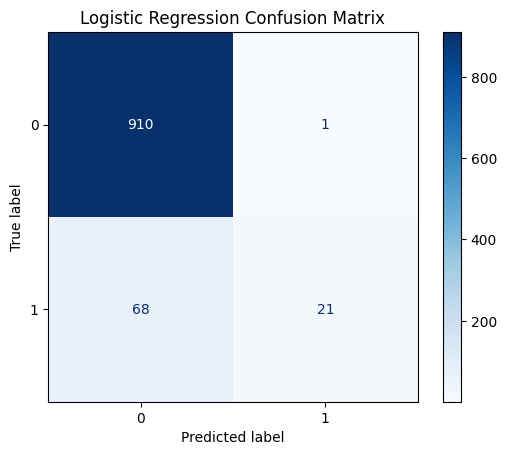

In [ ]:
# Visualize confusion matrix to understand prediction errors
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("Logistic Regression Confusion Matrix")
plt.show()

ROC Curve Plot

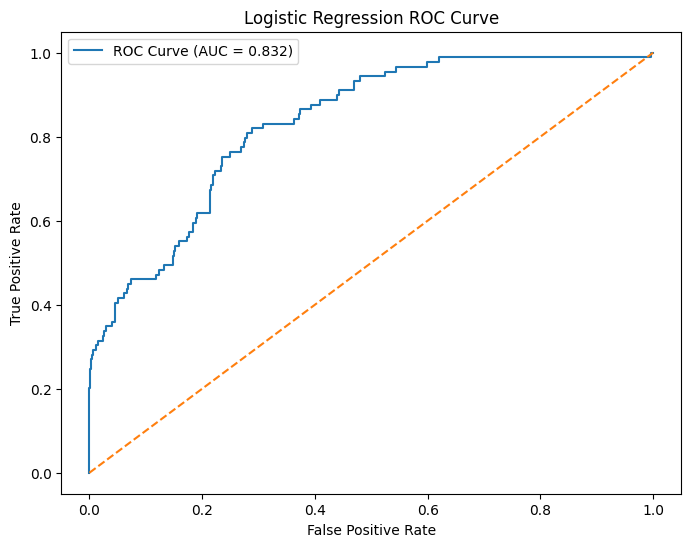

In [ ]:
#Plot ROC curve to evaluate model's ability to distinguish class 
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Logistic Regression ROC Curve")
plt.legend()
plt.show()

Top 10 Coefficients Plot

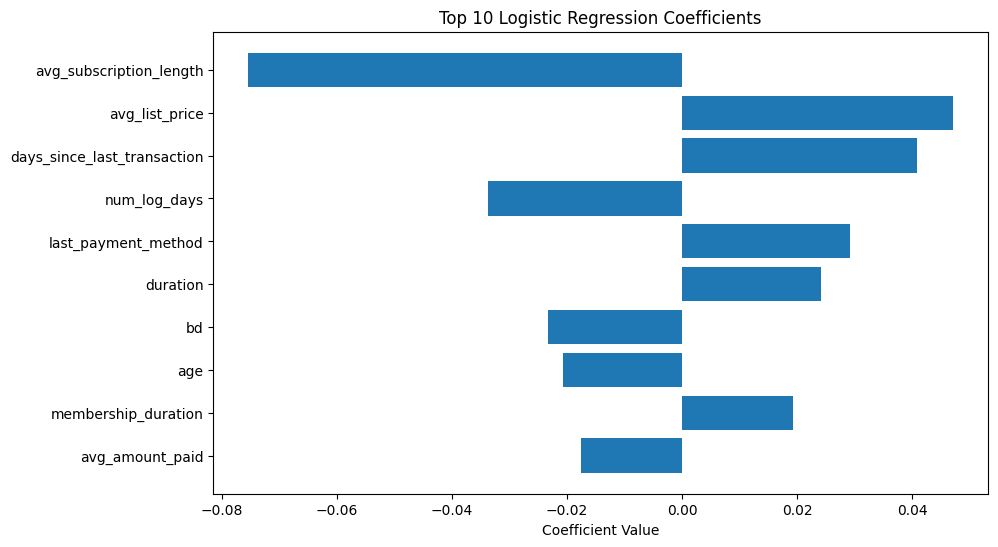

In [ ]:
# Extract model coefficients to understand feature impact
# Positive values increase churn likelihood, negative values decrease it

import pandas as pd
import matplotlib.pyplot as plt

coef_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": log_model.coef_[0]
})

# Sort by absolute importance
coef_df["Abs_Coefficient"] = coef_df["Coefficient"].abs()
top_coef = coef_df.sort_values("Abs_Coefficient", ascending=False).head(10)

plt.figure(figsize=(10, 6))
plt.barh(top_coef["Feature"], top_coef["Coefficient"])
plt.xlabel("Coefficient Value")
plt.title("Top 10 Logistic Regression Coefficients")
plt.gca().invert_yaxis()
plt.show()

# Insights 
- Accuracy: ~93%
- ROC-AUC: ~0.83
- F1-Score (churn): ~0.38
- Precision (churn): High (~0.95)
- Recall (churn): Low (~0.24)

The logistic regression model provides a strong and interpretable baseline, demonstrating good overall classification and ranking ability. However, its lower recall for churn highlights the need for more advanced models to better capture at-risk customers. This baseline serves as a reference point for comparing future modeling approaches and improving churn detection performance.